In [1]:
import qiskit
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram

print("Qiskit Version:", qiskit.__version__)
simulator = AerSimulator()
print(simulator)


Qiskit Version: 2.5.1
AerSimulator('aer_simulator')


|+> measured in X basis: {'0': 1024}
|-> measured in X basis: {'1': 1024}


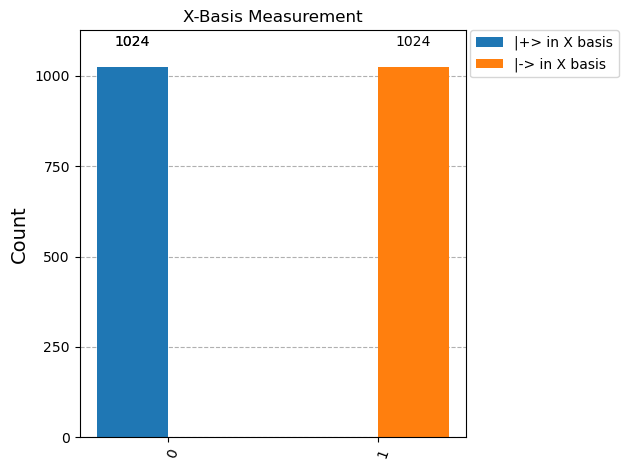

In [2]:
def measure_in_x_basis(state_name, shots=1024):
    qc = QuantumCircuit(1, 1)

    if state_name == "plus":
        qc.h(0)          # Prepare |+>
    elif state_name == "minus":
        qc.h(0)
        qc.z(0)          # Prepare |->

    qc.h(0)              # Convert X-basis measurement to Z-basis measurement
    qc.measure(0, 0)

    counts = simulator.run(qc, shots=shots).result().get_counts()
    return qc, counts

plus_circuit, plus_counts = measure_in_x_basis("plus")
minus_circuit, minus_counts = measure_in_x_basis("minus")

print("|+> measured in X basis:", plus_counts)
print("|-> measured in X basis:", minus_counts)

plot_histogram(
    [plus_counts, minus_counts],
    legend=["|+> in X basis", "|-> in X basis"],
    title="X-Basis Measurement"
)
